In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
plt.rcParams.update({
        "text.usetex": False,          # disable system LaTeX
        "mathtext.fontset": "stix",    # nicer math font
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "grid.color": "lightgray",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
    })

In [3]:
# theoretical recall @ 10 vs branching & recall target
# on SIFT/MSTuring Static sets
# surge & quake

In [4]:
# surge results: (benchmarking sets)
# to generate: 
# 1. ./bin/theoretical_partitioning_quality.cpp
# 2. python recall_target_oracle.py to compute oracle results for recall target mode

# TODO: build quake and measure resulting recall for the recall targets

# /dataset/surge-dont_copy/theoretical_partition_quality_sift-500M_10_*
# /dataset/surge-dont_copy/theoretical_partition_quality_msturing-500M_10_*

# /dataset/surge/results/theoretical_partition_quality_sift-100M_10_20260519_105832
# /dataset/surge/results/theoretical_partition_quality_msturing-100M_10_20260519_105024

# sift/msturing 500M:
# /dataset/surge/results/theoretical_partition_quality_sift-500M_10_20260519_130459
# /dataset/surge/results/theoretical_partition_quality_msturing-500M_10_20260519_131044

# new after consistency fix -------
# /dataset/surge/results/theoretical_partition_quality_msturing-100M_10_20260520_130929
# 

In [5]:
msturing_surge_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_msturing-100M_10_20260519_105024/routing_metrics.csv"
msturing_surge = pd.read_csv(msturing_surge_path)

msturing_surge_oracle_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_msturing-100M_10_20260519_105024/oracle_target_recall_results.csv"
msturing_surge_oracle = pd.read_csv(msturing_surge_oracle_path)

bigann_surge_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_sift-100M_10_20260519_105832/routing_metrics.csv"
bigann_surge = pd.read_csv(bigann_surge_path)

big_ann_surge_oracle_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_sift-100M_10_20260519_105832/oracle_target_recall_results.csv"
bigann_surge_oracle = pd.read_csv(big_ann_surge_oracle_path)

In [6]:
msturing_surge_new_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_msturing-100M_10_20260520_130929/routing_metrics.csv"
msturing_surge_new = pd.read_csv(msturing_surge_new_path)

msturing_surge_oracle_new_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_msturing-100M_10_20260520_130929/oracle_target_recall_results.csv"
msturing_surge_oracle_new = pd.read_csv(msturing_surge_oracle_new_path)

## MSTuring-100M

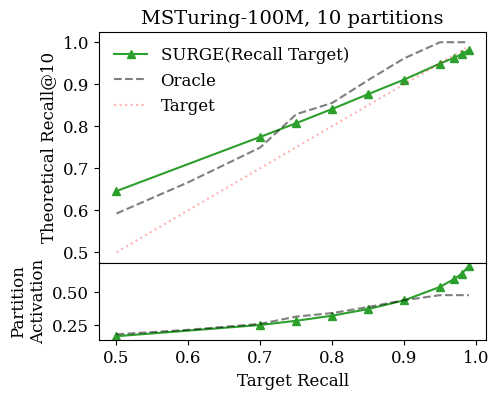

In [35]:
fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)
# adjust size of the figure
fig.set_size_inches(5, 4)

ax_top.plot(msturing_surge[msturing_surge["mode"] == "recall_target"]["param"],
         msturing_surge[msturing_surge["mode"] == "recall_target"]["recall"],
         marker="^", label="SURGE(Recall Target)", color="C2"
)
ax_top.plot(msturing_surge_oracle["recall_target"], 
         msturing_surge_oracle["mean_recall"], color="black", ls="--", alpha=.5, label="Oracle")

ax_top.plot(msturing_surge[msturing_surge["mode"] == "recall_target"]["param"],
            msturing_surge[msturing_surge["mode"] == "recall_target"]["param"],
            color="red", alpha=.3, ls=":", label="Target"
    )

# add grid
# ax_top.grid(True, which="both", linestyle="--", linewidth=0.5)
# ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5)

ax_bottom.plot(msturing_surge[msturing_surge["mode"] == "recall_target"]["param"],
         msturing_surge[msturing_surge["mode"] == "recall_target"]["activation"],
         marker="^", color="C2"
)
ax_bottom.plot(msturing_surge_oracle["recall_target"], 
         msturing_surge_oracle["mean_partitions"]/10, color="black", ls="--", alpha=.5)

ax_bottom.set_xlabel("Target Recall")
ax_top.set_ylabel("Theoretical Recall@10")
ax_bottom.set_ylabel("Partition\nActivation")
ax_top.set_title("MSTuring-100M, 10 partitions")

ax_top.legend(loc="upper left", frameon=False)

# save
plt.savefig("msturing100_recall_target_analysis.pdf", bbox_inches="tight")

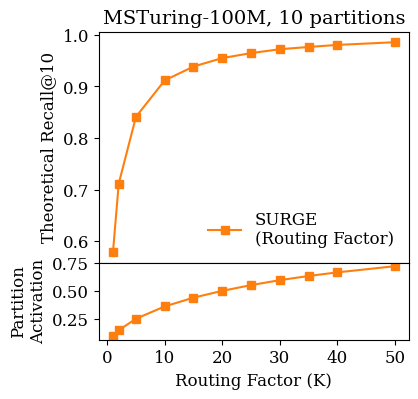

In [33]:
fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)
# adjust size of the figure
fig.set_size_inches(4, 4)

ax_top.plot(msturing_surge[msturing_surge["mode"] == "branching_factor"]["param"],
         msturing_surge[msturing_surge["mode"] == "branching_factor"]["recall"],
         marker="s", label="SURGE\n(Routing Factor)", color="C1")

# ax_top.plot(msturing_surge_new[msturing_surge_new["mode"] == "branching_factor"]["param"],
#          msturing_surge_new[msturing_surge_new["mode"] == "branching_factor"]["recall"],
#          marker="o", label="SURGE")

ax_bottom.plot(msturing_surge[msturing_surge["mode"] == "branching_factor"]["param"],
         msturing_surge[msturing_surge["mode"] == "branching_factor"]["activation"],
         marker="s", color="C1"
)

# ax_bottom.plot(msturing_surge_new[msturing_surge_new["mode"] == "branching_factor"]["param"],
#          msturing_surge_new[msturing_surge_new["mode"] == "branching_factor"]["activation"],
#          marker="o"
# )

# add grid
# ax_top.grid(True, which="both", linestyle="--", linewidth=0.5)
# ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5)

ax_bottom.set_xlabel("Routing Factor (K)")
ax_top.set_ylabel("Theoretical Recall@10")
ax_bottom.set_ylabel("Partition\nActivation")
ax_top.set_title("MSTuring-100M, 10 partitions")

ax_top.legend(frameon=False)
# save
plt.savefig("msturing100_branching_factor_analysis.pdf", bbox_inches="tight")

## SIFT-100M

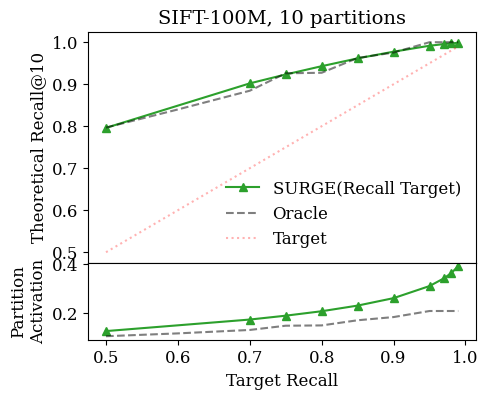

In [36]:
fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)
fig.set_size_inches(5, 4)

ax_top.plot(bigann_surge[bigann_surge["mode"] == "recall_target"]["param"],
         bigann_surge[bigann_surge["mode"] == "recall_target"]["recall"],
          marker="^", label="SURGE(Recall Target)", color="C2")
ax_top.plot(bigann_surge_oracle["recall_target"], 
         bigann_surge_oracle["mean_recall"], color="black", ls="--", alpha=.5, label="Oracle")

ax_top.plot(msturing_surge[msturing_surge["mode"] == "recall_target"]["param"],
            msturing_surge[msturing_surge["mode"] == "recall_target"]["param"],
            color="red", alpha=.3, ls=":", label="Target"
    )

ax_bottom.plot(bigann_surge[bigann_surge["mode"] == "recall_target"]["param"],
         bigann_surge[bigann_surge["mode"] == "recall_target"]["activation"],
         marker="^", color="C2"
)
ax_bottom.plot(bigann_surge_oracle["recall_target"], 
         bigann_surge_oracle["mean_partitions"]/10, color="black", ls="--", alpha=.5)

# add grid
# ax_top.grid(True, which="both", linestyle="--", linewidth=0.5)
# ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5)

ax_bottom.set_xlabel("Target Recall")
ax_top.set_ylabel("Theoretical Recall@10")
ax_bottom.set_ylabel("Partition\nActivation")
ax_top.set_title("SIFT-100M, 10 partitions")

ax_top.legend(frameon=False)

# save
plt.savefig("sift100_recall_target_analysis.pdf", bbox_inches="tight")

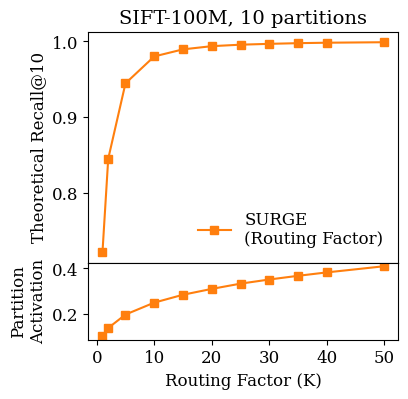

In [31]:
fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)
fig.set_size_inches(4, 4)

ax_top.plot(bigann_surge[bigann_surge["mode"] == "branching_factor"]["param"],
         bigann_surge[bigann_surge["mode"] == "branching_factor"]["recall"],
          marker="s", label="SURGE\n(Routing Factor)", color="C1")

ax_bottom.plot(bigann_surge[bigann_surge["mode"] == "branching_factor"]["param"],
         bigann_surge[bigann_surge["mode"] == "branching_factor"]["activation"],
         marker="s", color="C1"
)

# add grid
# ax_top.grid(True, which="both", linestyle="--", linewidth=0.5)
# ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5)

ax_bottom.set_xlabel("Routing Factor (K)")
ax_top.set_ylabel("Theoretical Recall@10")
ax_bottom.set_ylabel("Partition\nActivation")
ax_top.set_title("SIFT-100M, 10 partitions")

ax_top.legend(frameon=False)
# save
plt.savefig("sift100_branching_factor_analysis.pdf", bbox_inches="tight")

In [22]:
bigann_500M_surge_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_sift-500M_10_20260519_130459/routing_metrics.csv"
bigann_500M_surge = pd.read_csv(bigann_500M_surge_path)

bigann_500M_surge_oracle_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_sift-500M_10_20260519_130459/oracle_target_recall_results.csv"
bigann_500M_surge_oracle = pd.read_csv(bigann_500M_surge_oracle_path)

msturing_500M_surge_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_msturing-500M_10_20260520_133756/routing_metrics.csv"
msturing_500M_surge = pd.read_csv(msturing_500M_surge_path)

msturing_500M_surge_oracle_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_msturing-500M_10_20260520_133756/oracle_target_recall_results.csv"
msturing_500M_surge_oracle = pd.read_csv(msturing_500M_surge_oracle_path)

## SIFT-500M

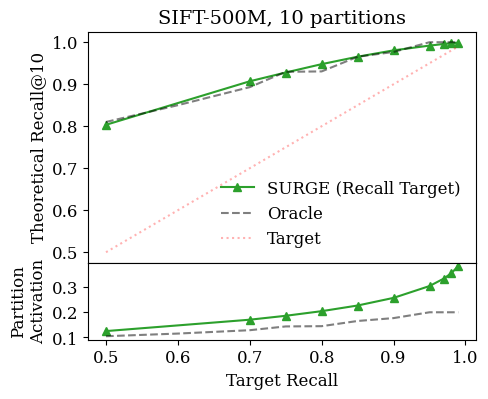

In [37]:
fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)
fig.set_size_inches(5, 4)

ax_top.plot(bigann_500M_surge[bigann_500M_surge["mode"] == "recall_target"]["param"],
         bigann_500M_surge[bigann_500M_surge["mode"] == "recall_target"]["recall"],
         marker="^", label="SURGE (Recall Target)", color="C2")

ax_top.plot(bigann_500M_surge_oracle["recall_target"],
         bigann_500M_surge_oracle["mean_recall"], color="black", ls="--", alpha=.5, label="Oracle")

ax_top.plot(bigann_500M_surge[bigann_500M_surge["mode"] == "recall_target"]["param"],
         bigann_500M_surge[bigann_500M_surge["mode"] == "recall_target"]["param"],
         ls=":", color="red", alpha=0.3, label="Target")

ax_bottom.plot(bigann_500M_surge[bigann_500M_surge["mode"] == "recall_target"]["param"],
         bigann_500M_surge[bigann_500M_surge["mode"] == "recall_target"]["activation"],
         marker="^", color="C2"
)
ax_bottom.plot(bigann_500M_surge_oracle["recall_target"], 
         bigann_500M_surge_oracle["mean_partitions"]/10, color="black", ls="--", alpha=.5)

# add grid
# ax_top.grid(True, which="both", linestyle="--", linewidth=0.5)
# ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5)

ax_bottom.set_xlabel("Target Recall")
ax_top.set_ylabel("Theoretical Recall@10")
ax_bottom.set_ylabel("Partition\nActivation")
ax_top.set_title("SIFT-500M, 10 partitions")

ax_top.legend(frameon=False)
# save
plt.savefig("sift500_recall_target_analysis.pdf", bbox_inches="tight")

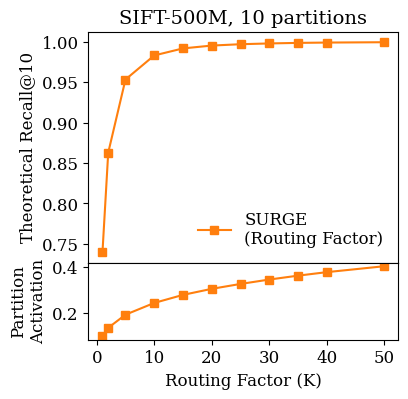

In [29]:
fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)

fig.set_size_inches(4, 4)

ax_top.plot(bigann_500M_surge[bigann_500M_surge["mode"] == "branching_factor"]["param"],
         bigann_500M_surge[bigann_500M_surge["mode"] == "branching_factor"]["recall"],
         marker="s", label="SURGE\n(Routing Factor)", color="C1")

ax_bottom.plot(bigann_500M_surge[bigann_500M_surge["mode"] == "branching_factor"]["param"],
         bigann_500M_surge[bigann_500M_surge["mode"] == "branching_factor"]["activation"],
         marker="s", color="C1"
)

# add grid
# ax_top.grid(True, which="both", linestyle="--", linewidth=0.5)
# ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5)

ax_bottom.set_xlabel("Routing Factor (K)")
ax_top.set_ylabel("Theoretical Recall@10")
ax_bottom.set_ylabel("Partition\nActivation")
ax_top.set_title("SIFT-500M, 10 partitions")

ax_top.legend(frameon=False)
# save
plt.savefig("sift500_branching_factor_analysis.pdf", bbox_inches="tight")

## MSTuring-500M

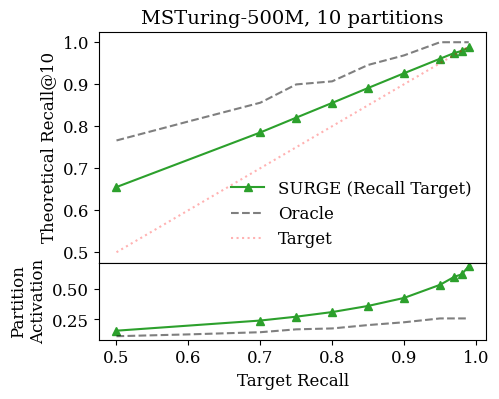

In [38]:
fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)

fig.set_size_inches(5, 4)

ax_top.plot(msturing_500M_surge[msturing_500M_surge["mode"] == "recall_target"]["param"],
         msturing_500M_surge[msturing_500M_surge["mode"] == "recall_target"]["recall"], 
         marker="^", label="SURGE (Recall Target)", color="C2")

ax_top.plot(msturing_500M_surge_oracle["recall_target"], 
         msturing_500M_surge_oracle["mean_recall"], color="black", ls="--", alpha=.5, label="Oracle")

ax_top.plot(msturing_500M_surge[msturing_500M_surge["mode"] == "recall_target"]["param"],
         msturing_500M_surge[msturing_500M_surge["mode"] == "recall_target"]["param"],
         ls=":", color="red", alpha=0.3, label="Target")

ax_bottom.plot(msturing_500M_surge[msturing_500M_surge["mode"] == "recall_target"]["param"],
         msturing_500M_surge[msturing_500M_surge["mode"] == "recall_target"]["activation"],
         marker="^", color="C2"
)
ax_bottom.plot(msturing_500M_surge_oracle["recall_target"], 
         msturing_500M_surge_oracle["mean_partitions"]/10, color="black", ls="--", alpha=.5)

# add grid
# ax_top.grid(True, which="both", linestyle="--", linewidth=0.5)
# ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5)

ax_bottom.set_xlabel("Target Recall")
ax_top.set_ylabel("Theoretical Recall@10")
ax_bottom.set_ylabel("Partition\nActivation")
ax_top.set_title("MSTuring-500M, 10 partitions")

ax_top.legend(frameon=False)
# save
plt.savefig("msturing500_recall_target_analysis.pdf", bbox_inches="tight")

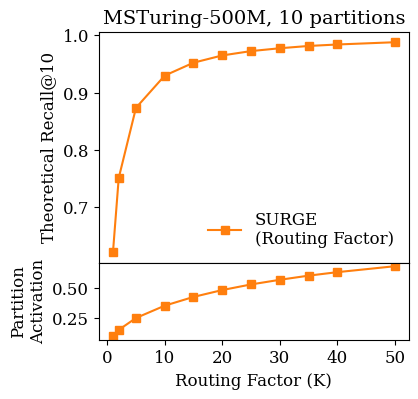

In [27]:
fig, (ax_top, ax_bottom) = plt.subplots(
	2,
	1,
	sharex=True,
	gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
)
fig.set_size_inches(4, 4)

ax_top.plot(msturing_500M_surge[msturing_500M_surge["mode"] == "branching_factor"]["param"],
         msturing_500M_surge[msturing_500M_surge["mode"] == "branching_factor"]["recall"], 
         marker="s", label="SURGE\n(Routing Factor)", color="C1")

ax_bottom.plot(msturing_500M_surge[msturing_500M_surge["mode"] == "branching_factor"]["param"],
         msturing_500M_surge[msturing_500M_surge["mode"] == "branching_factor"]["activation"],
         marker="s", color="C1"
)

# add grid
# ax_top.grid(True, which="both", linestyle="--", linewidth=0.5)
# ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5)

ax_bottom.set_xlabel("Routing Factor (K)")
ax_top.set_ylabel("Theoretical Recall@10")
ax_bottom.set_ylabel("Partition\nActivation")
ax_top.set_title("MSTuring-500M, 10 partitions")

ax_top.legend(frameon=False)

# save
plt.savefig("msturing500_branching_factor_analysis.pdf", bbox_inches="tight")